In [16]:
# 1) ensure Python can see your project root
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("→ Added to sys.path:", project_root)
print("→ cwd is:", os.getcwd())

from environments.auv_env.auv_env    import AUVEnv
from environments.auv_env.auv_config import AUVEnvConfig
from agents.auv_dqn_agent    import AuvDQNAgent
from agents.enhanced_dqn_agent import EnhancedDQNAgent
from agents.td3_agent       import TD3Agent
from agents.dqn_agent      import train_dqn
from environments.grid_env.grid_utils     import plot_rewards, evaluate_agent
from utils.graphics_utils import record_headless

→ Added to sys.path: /Users/eirikvarnes/code/auv-rl-project
→ cwd is: /Users/eirikvarnes/code/auv-rl-project/notebooks


In [7]:
static_cfg = AUVEnvConfig(n_beams=20)
static_env = AUVEnv(static_cfg)

static_agent = AuvDQNAgent(
    static_env,
    hidden_dims=[128,128, 64],
    lr=1e-3,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    batch_size=64,
    buffer_size=20000,
    target_update=20,
)


DQN Training: 100%|██████████| 800/800 [03:31<00:00,  3.79it/s, Reward=-156.9, ε=0.018] 


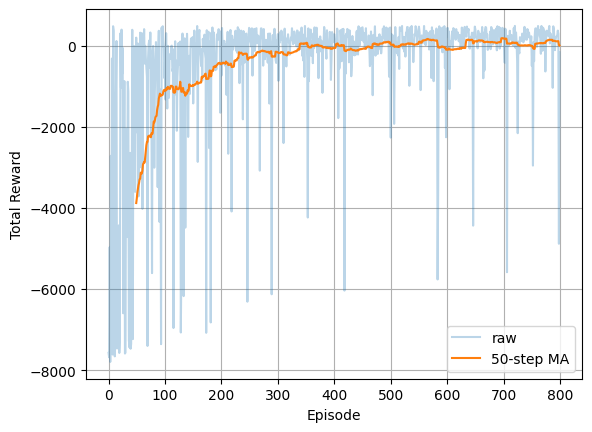

In [8]:
rewards = train_dqn(static_env, static_agent, episodes=800, max_steps= 500)
plot_rewards(rewards, window=50)
static_agent.save("../models/static_auv_dqn.pth")

In [9]:
static_agent.load("../models/static_auv_dqn.pth")

In [38]:
record_headless(static_env, static_agent, out_path='../gifs/static_auv.gif')

Headless recording saved to ../gifs/static_auv.gif


In [15]:
sr, avg_steps = evaluate_agent(static_env, static_agent, episodes = 500, max_steps=500)
print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

Success rate: 96.6%, Avg steps: 33.1


# **Enhanced Agent**

DQN Training:   0%|          | 0/800 [00:00<?, ?it/s]/Users/eirikvarnes/code/auv-rl-project/agents/enhanced_dqn_agent.py:172: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  states      = torch.tensor(batch.state, dtype=torch.float32, device=self.device)
DQN Training: 100%|██████████| 800/800 [05:17<00:00,  2.52it/s, Reward=402.1, ε=0.010]  


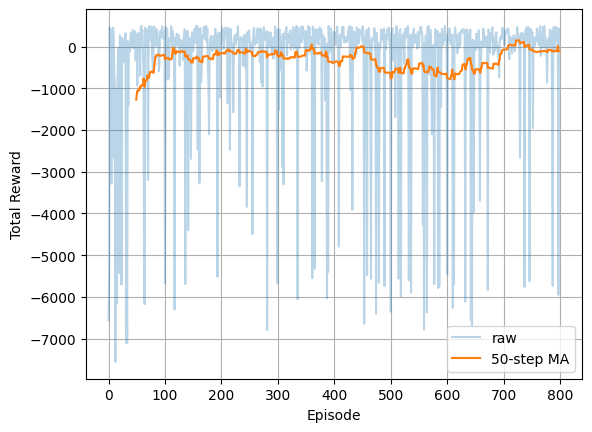

In [2]:
static_cfg = AUVEnvConfig(n_beams=20)
static_env = AUVEnv(static_cfg)

enhanced_agent = EnhancedDQNAgent(
    static_env,
    hidden_dims=[128, 128, 64],
    lr=1e-3,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    batch_size=64,
    buffer_size=5000,
    target_update=20,
)
rewards = train_dqn(static_env, enhanced_agent, episodes=800, max_steps=500)
plot_rewards(rewards, window=50)
enhanced_agent.save("../models/enhanced_auv_dqn.pth")

In [5]:
record_headless(static_env, enhanced_agent, out_path='../gifs/enhanced_auv.gif')

Headless recording saved to ../gifs/enhanced_auv.gif


# **TD3 Agent**

In [ ]:
td3_agent = TD3Agent(
    static_env,
    hidden_dims=[128, 128, 64],
    lr=1e-3,
    gamma=0.95,
    batch_size=64,
    buffer_size=20000,
    target_update=20,
)
rewards = train_dqn(static_env, td3_agent, episodes=800, max_steps=500)
plot_rewards(rewards, window=50)

In [ ]:
record_headless(static_env, td3_agent, out_path='../gifs/td3_auv.gif')

In [ ]:
sr, avg_steps = evaluate_agent(static_env, enhanced_agent, episodes=100, max_steps=500)
print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

In [9]:
random_cfg = AUVEnvConfig(random_map=True)
random_env = AUVEnv(random_cfg)

random_agent = AuvDQNAgent(
    random_env,
    hidden_dims=[64,64],
    lr=1e-3,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    batch_size=64,
    buffer_size=5000,
    target_update=20,
)


DQN Training: 100%|██████████| 1000/1000 [02:34<00:00,  6.47it/s, Reward=99.5, ε=0.010]  


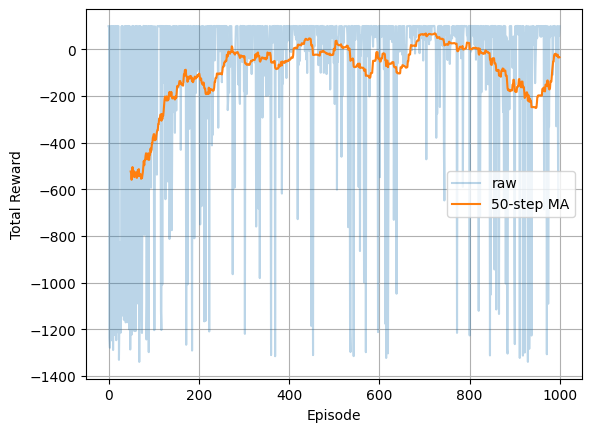

In [10]:
rewards = train_dqn(random_env, random_agent, episodes=1000, max_steps= 500)
plot_rewards(rewards, window=50)
random_agent.save("../models/static_auv_dqn.pth")

In [13]:
record_headless(random_env, random_agent, out_path='../gifs/random_auv.gif')

Headless recording saved to ../gifs/random_auv.gif


In [12]:
sr, avg_steps = evaluate_agent(random_env, random_agent, episodes = 500, max_steps=200)
print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

Success rate: 60.8%, Avg steps: 7.8
